# Analisi esplorativa del dataset PIMA Indians Diabetes

In questa prima fase ho analizzato il dataset per capire come è organizzato, quali informazioni contiene e quali problemi di qualità devono essere affrontati prima di addestrare un modello. Ho usato un'analisi descrittiva: le correlazioni che osservo possono suggerire associazioni, ma non dimostrano un rapporto di causa-effetto.

## 1. Caricamento e descrizione

Ho caricato il dataset PIMA Indians Diabetes da una fonte pubblica, specificando i nomi delle colonne perché il file originale non contiene un'intestazione. Le otto variabili cliniche saranno i possibili predittori, mentre `Diabete_Esito` è la variabile target binaria che voglio prevedere.

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
url_dataset = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
nomi_colonne = ['Gravidanze','Glucosio','Pressione_Sanguigna','Spessore_Pelle','Insulina','BMI','Fattore_Ereditario_Diabete','Eta','Diabete_Esito']
df = pd.read_csv(url_dataset, names=nomi_colonne)
display(df.head())

,Gravidanze,Glucosio,Pressione_Sanguigna,Spessore_Pelle,Insulina,BMI,Fattore_Ereditario_Diabete,Eta,Diabete_Esito
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [14]:
print(f'Righe: {df.shape[0]} | Colonne: {df.shape[1]}')
df.info()
display(df.describe().T)

Righe: 768 | Colonne: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gravidanze                  768 non-null    int64  
 1   Glucosio                    768 non-null    int64  
 2   Pressione_Sanguigna         768 non-null    int64  
 3   Spessore_Pelle              768 non-null    int64  
 4   Insulina                    768 non-null    int64  
 5   BMI                         768 non-null    float64
 6   Fattore_Ereditario_Diabete  768 non-null    float64
 7   Eta                         768 non-null    int64  
 8   Diabete_Esito               768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,count,mean,std,min,25%,50%,75%,max
Gravidanze,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucosio,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
Pressione_Sanguigna,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
Spessore_Pelle,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulina,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
Fattore_Ereditario_Diabete,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Eta,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Diabete_Esito,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 2. Valori mancanti e zeri non plausibili

Ho controllato i valori mancanti perché un modello addestrato su dati incompleti può produrre risultati poco affidabili. In alcune misure cliniche lo zero non è plausibile: per esempio un BMI o un livello di glucosio pari a zero indica molto probabilmente un'informazione non registrata, non una misura reale. Ho quindi trasformato questi zeri in `NaN`, senza modificare la variabile target. Nella fase di machine learning questi valori saranno imputati usando soltanto i dati di addestramento.

,Valori mancanti
Insulina,374
Spessore_Pelle,227
Pressione_Sanguigna,35
BMI,11
Glucosio,5
Gravidanze,0
Fattore_Ereditario_Diabete,0
Eta,0
Diabete_Esito,0


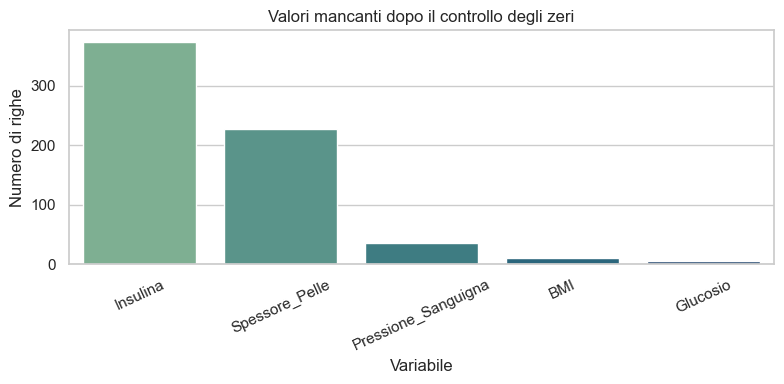

In [15]:
colonne_con_zeri_errati = ['Glucosio','Pressione_Sanguigna','Spessore_Pelle','Insulina','BMI']
df[colonne_con_zeri_errati] = df[colonne_con_zeri_errati].replace(0, np.nan)
missing = df.isna().sum().sort_values(ascending=False)
display(missing.to_frame('Valori mancanti'))

plt.figure(figsize=(8,4))
sns.barplot(x=missing[missing>0].index, y=missing[missing>0].values, hue=missing[missing>0].index, legend=False, palette='crest')
plt.title('Valori mancanti dopo il controllo degli zeri'); plt.xlabel('Variabile'); plt.ylabel('Numero di righe'); plt.xticks(rotation=25); plt.tight_layout(); plt.show()

## 3. Distribuzione e outlier

Ho usato gli istogrammi per capire se le variabili sono concentrate in un intervallo, asimmetriche o caratterizzate da più gruppi di valori. Ho aggiunto i boxplot per individuare possibili outlier. Non elimino automaticamente questi valori: in un contesto medico potrebbero rappresentare pazienti reali e la loro rimozione richiederebbe una giustificazione clinica.

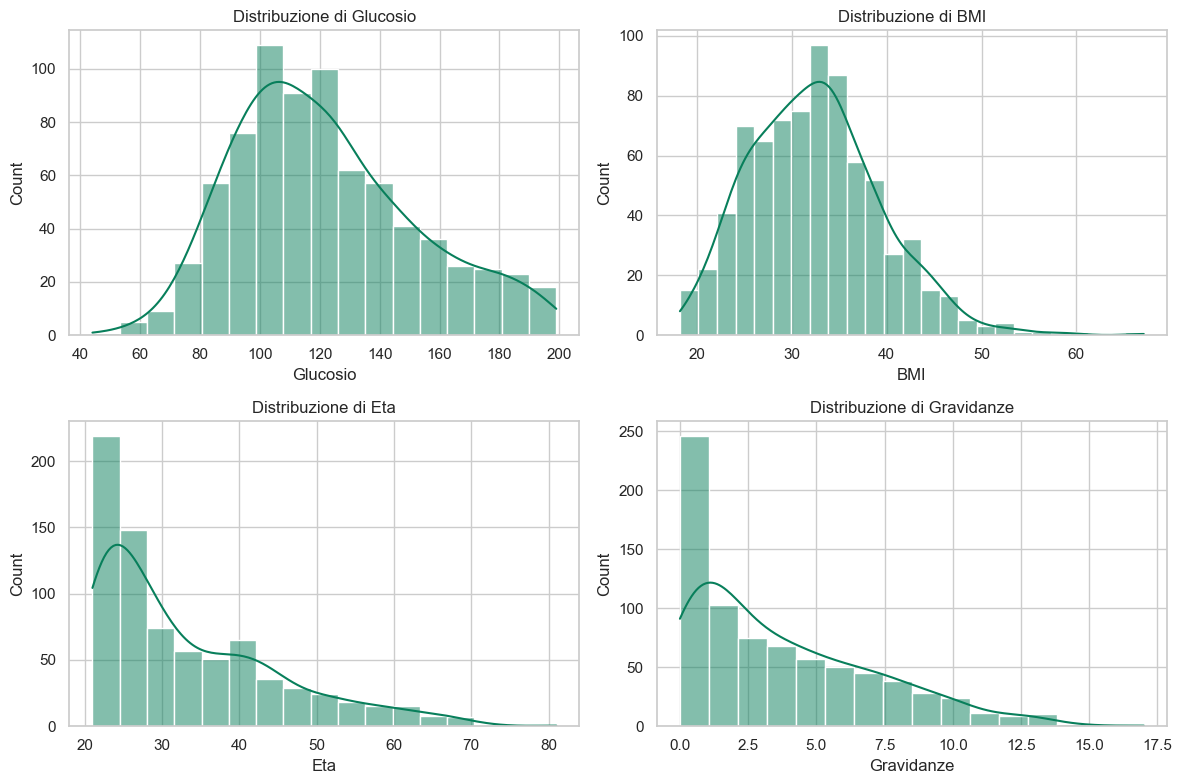

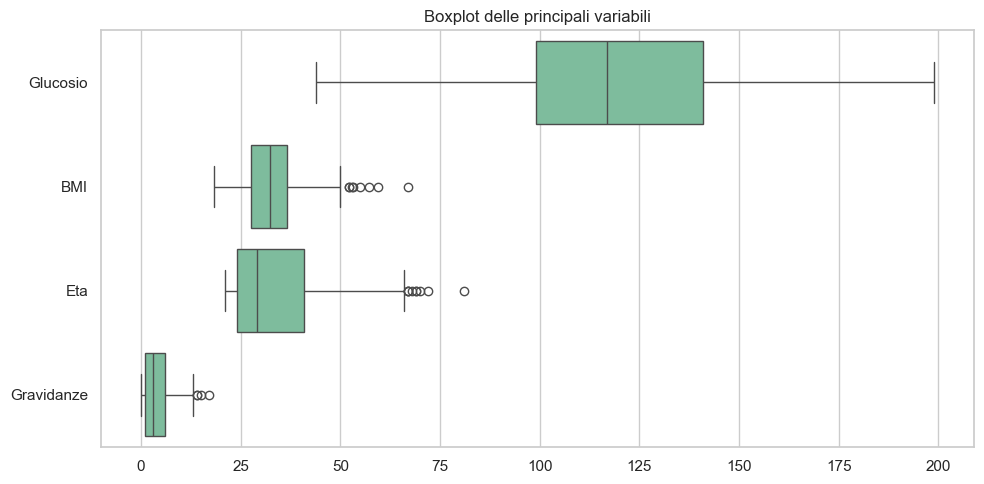

In [16]:
variabili = ['Glucosio','BMI','Eta','Gravidanze']
fig, axes = plt.subplots(2,2,figsize=(12,8))
for ax, colonna in zip(axes.ravel(), variabili):
    sns.histplot(data=df, x=colonna, kde=True, color='#087f5b', ax=ax)
    ax.set_title(f'Distribuzione di {colonna}')
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df[variabili], orient='h', color='#74c69d')
plt.title('Boxplot delle principali variabili'); plt.tight_layout(); plt.show()

## 4. Variabile target

Ho verificato la frequenza delle due classi perché il modello dovrà distinguere tra assenza e presenza del diabete. Se una classe fosse molto più frequente dell'altra, l'accuracy da sola potrebbe essere fuorviante: per questo nella fase ML userò anche precision, recall, F1 e ROC-AUC.

,Conteggio,Percentuale
Diabete_Esito,,
0,500,65.1
1,268,34.9


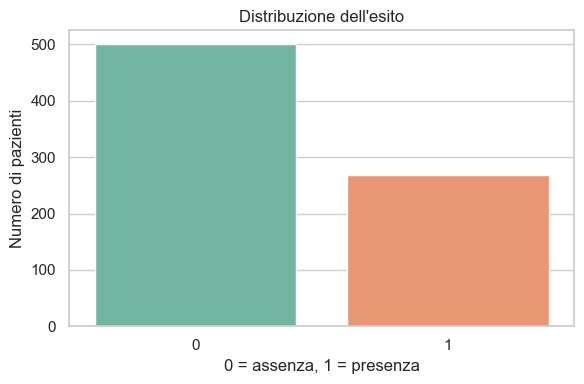

In [17]:
conteggi = df['Diabete_Esito'].value_counts().sort_index()
display(pd.DataFrame({'Conteggio':conteggi, 'Percentuale':(conteggi/len(df)*100).round(2)}))
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Diabete_Esito', hue='Diabete_Esito', legend=False, palette='Set2')
plt.title("Distribuzione dell'esito"); plt.xlabel('0 = assenza, 1 = presenza'); plt.ylabel('Numero di pazienti'); plt.tight_layout(); plt.show()

## 5. Correlazioni e relazione con il glucosio

Ho calcolato la matrice di correlazione per confrontare tutte le variabili numeriche e individuare le associazioni lineari più evidenti. Ho poi confrontato il glucosio tra le due classi con un boxplot, perché è importante osservare non solo un coefficiente numerico ma anche la distribuzione dei valori. Interpreto comunque questi risultati come associazioni nel campione: non dimostrano un rapporto di causa-effetto.

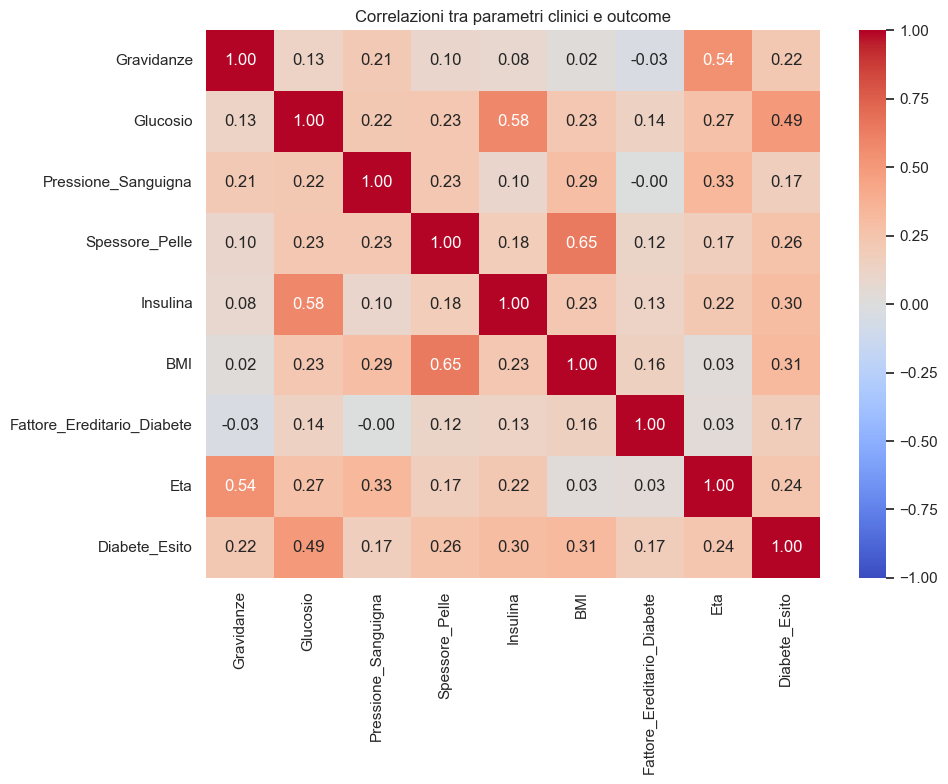

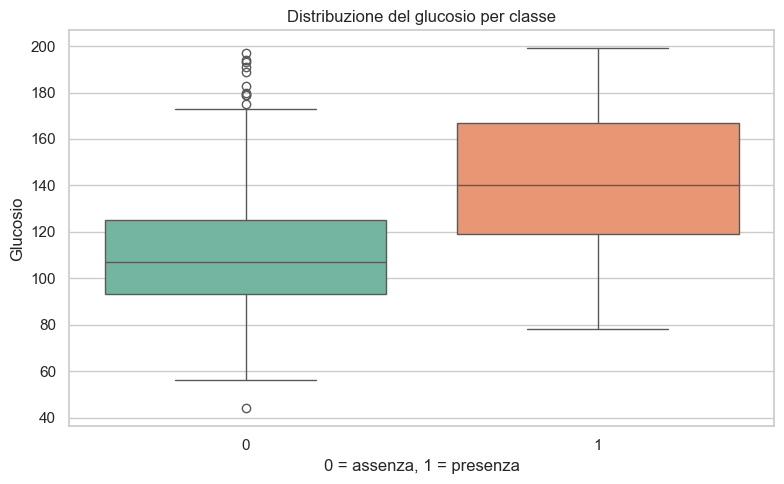

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlazioni tra parametri clinici e outcome'); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Diabete_Esito', y='Glucosio', hue='Diabete_Esito', legend=False, palette='Set2')
plt.title('Distribuzione del glucosio per classe'); plt.xlabel('0 = assenza, 1 = presenza'); plt.tight_layout(); plt.show()

## 6. Conclusioni

Da questa analisi ho capito che il dataset contiene 768 osservazioni e 8 predittori clinici. Il target è binario e le classi non sono perfettamente bilanciate, quindi nella valutazione non mi affiderò soltanto all'accuracy. Ho individuato zeri non plausibili in alcune misure e li ho trasformati in valori mancanti, mentre i possibili outlier saranno valutati senza eliminarli automaticamente. Infine, le associazioni osservate nella matrice di correlazione mi aiutano a motivare il preprocessing e la scelta dei modelli, ma non possono essere interpretate come relazioni causali.